In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, norm
from skopt import gp_minimize
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score

### What is Bayesian Thinking?

**Bayesian Thinking** is a framework for updating your beliefs as you see new data. Instead of saying *"there is one true fixed answer,"* it says, *"I have a degree of belief, and I update it when I see evidence."*


| Aspect | Frequentist | Bayesian |
|--------|-------------|----------|
| **Parameters** | Fixed, unknown constants | Random variables with distributions |
| **Data** | Random | Fixed (observed) |
| **Uncertainty** | Confidence intervals | Credible intervals |
| **Prior knowledge** | ❌ Not used | ✅ Used explicitly |


$$
\underbrace{P(\theta \mid \text{Data})}_{\text{Posterior}} \propto \underbrace{P(\text{Data} \mid \theta)}_{\text{Likelihood}} \times \underbrace{P(\theta)}_{\text{Prior}}
$$

| Term | Meaning |
|------|---------|
| **Prior** | What you believed *before* seeing the data |
| **Likelihood** | How likely the data is, given your parameters |
| **Posterior** | What you believe *after* seeing the data |



The Golden Rule

> Bayesian methods treat unknown parameters as **random variables with distributions**, not as fixed unknown constants.



In [2]:
# Frequentist: "There is ONE true answer. Find it."
# Bayesian: "There are MANY possible answers. Update your belief."

**Frequentist:** The probability of a coin landing heads is **exactly 0.5**. You can't change it. You estimate it by flipping it 1,000,000 times.

**Bayesian:** You start with a belief (e.g., *"I think it's 0.5"*). You flip the coin 10 times and see 8 heads. You update your belief slightly toward 0.8. If you flip 1,000 times and see 800 heads, your belief moves strongly toward 0.8.

$$
\text{MAP} = \text{Prior} + \text{Likelihood}
$$

**Regularization = MAP**

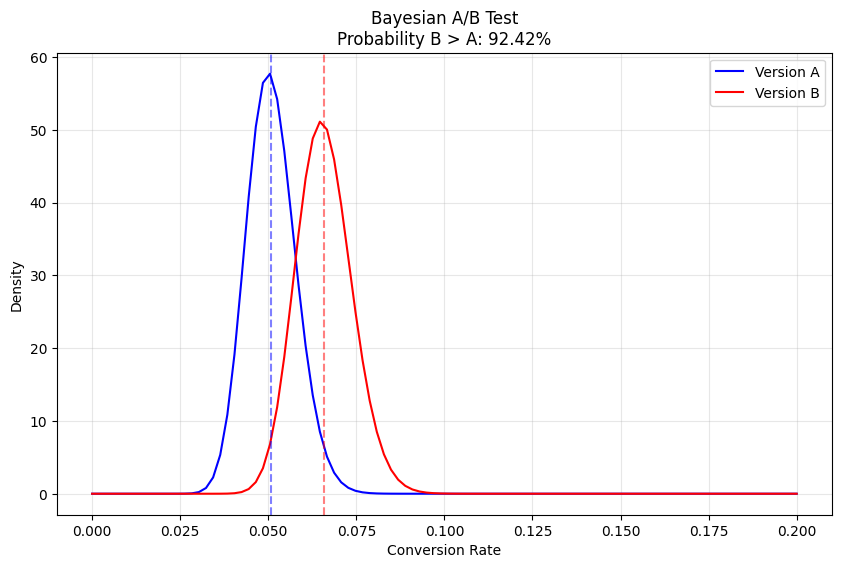

Probability B > A: 92.42%
Expected lift from switching to B: 31.9%


In [6]:
def bayesian_ab_test(A_visitors, A_conversions, B_visitors, B_conversions, n_simulations=100000):
    """
    Bayesian A/B testing comparing two versions.
    Returns: Probability B > A, and full distributions.
    """
    # Posterior distributions
    A_posterior = beta(1 + A_conversions, 1 + A_visitors - A_conversions)
    B_posterior = beta(1 + B_conversions, 1 + B_visitors - B_conversions)
    
    # Sample from posteriors
    A_samples = A_posterior.rvs(n_simulations)
    B_samples = B_posterior.rvs(n_simulations)
    
    # Probability B > A
    prob_B_better = np.mean(B_samples > A_samples)
    
    # Expected lift
    expected_lift = np.mean((B_samples - A_samples) / A_samples) * 100
    
    # Plot
    x = np.linspace(0, 0.2, 100)
    plt.figure(figsize=(10, 6))
    plt.plot(x, A_posterior.pdf(x), 'b-', label='Version A')
    plt.plot(x, B_posterior.pdf(x), 'r-', label='Version B')
    plt.axvline(A_posterior.mean(), color='b', linestyle='--', alpha=0.5)
    plt.axvline(B_posterior.mean(), color='r', linestyle='--', alpha=0.5)
    plt.title(f'Bayesian A/B Test\nProbability B > A: {prob_B_better:.2%}')
    plt.xlabel('Conversion Rate')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return prob_B_better, expected_lift

# Example
prob, lift = bayesian_ab_test(A_visitors=1000, A_conversions=50, B_visitors=1000, B_conversions=65)
print(f"Probability B > A: {prob:.2%}")
print(f"Expected lift from switching to B: {lift:.1f}%")

In [10]:
# Bayesian Hyperparameter Tuning
X, y = make_regression(n_samples=100, n_features=5, noise=0.1)

def objective(params):
    """
    Objective function for Bayesian Optimization.
    Lower is better (we minimize negative CV score).
    """
    n_estimators, max_depth, min_samples_split = params
    model = RandomForestRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        random_state=42
    )
    score = cross_val_score(model, X, y, cv=3, scoring='neg_mean_squared_error').mean()
    return -score  # Minimize negative = maximize MSE

space = [
    (10, 100),   # n_estimators
    (2, 20),     # max_depth
    (2, 10)      # min_samples_split
]

# Bayesian Optimization
result = gp_minimize(objective, space, n_calls=20, random_state=42)

print(f"Best params: n_estimators={int(result.x[0])}, max_depth={int(result.x[1])}, min_samples_split={int(result.x[2])}")
print(f"Best CV MSE: {-result.fun:.4f}")

Best params: n_estimators=100, max_depth=16, min_samples_split=2
Best CV MSE: -4898.7783


### Why Bayesian Optimization is Better than Grid/Random Search

| Method | How it works | Efficiency |
|--------|--------------|------------|
| **Grid Search** | Try every combination | Very inefficient ❌ |
| **Random Search** | Try random combinations | Better, but still wasteful ⚠️ |
| **Bayesian Optimization** | Uses past results to intelligently choose next | Most efficient ✅ |

### Bayesian vs Frequentist

| Concept | Frequentist | Bayesian |
|---------|-------------|----------|
| **Estimate** | Point estimate (MLE) | Distribution (Posterior) |
| **Uncertainty** | Confidence intervals | Credible intervals |
| **Prior knowledge** | Not used | Explicitly included |
| **Small sample size** | Poor performance | Can perform well with good priors |
| **Interpretation** | "Long-run frequency" | "Degree of belief" |
| **Computational cost** | Fast | Slow (sampling) |